In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

# Load the prepared dataset
df = pd.read_csv("/content/full_merge_price_tiers_baseQ3.csv")

import pandas as pd
import re

def clean_price(val):
    if pd.isna(val):
        return None
    # If multiple prices are concatenated, take the first number
    match = re.findall(r'\d+(?:,\d+)*(?:\.\d+)?', str(val))
    if match:
        return float(match[0].replace(',', ''))
    return None

df['Maximum Resale Price'] = df['Maximum Resale Price'].apply(clean_price)


In [ ]:
# Select relevant columns
cols = [
    'income_bracket', 'Price Tier',
    'age', 'dependents', 'hh_size', 'hh_income',
    'Maximum Resale Price'
]

# Keep only non-missing key values
df_analysis = df[cols].dropna(subset=['income_bracket', 'Price Tier', 'Maximum Resale Price'])

# Group and compute mean demographics for each (income_bracket × price_tier)
summary = (
    df_analysis
    .groupby(['income_bracket', 'Price Tier'])
    .agg({
        'Maximum Resale Price': 'mean',
        'age': 'mean',
        'dependents': 'mean',
        'hh_size': 'mean'
    })
    .rename(columns={
        'Maximum Resale Price': 'avg_resale_price',
        'age': 'avg_age',
        'dependents': 'avg_dependents',
        'hh_size': 'avg_household_size'
    })
    .reset_index()
)

print("✅ Summary of demographic differences by income bracket and price tier:\n")
print(summary)

# (Optional) Save
summary.to_csv("income_price_demographics_summary.csv", index=False)
print("\n💾 Saved summary to income_price_demographics_summary.csv")


✅ Summary of demographic differences by income bracket and price tier:

       income_bracket Price Tier  avg_resale_price    avg_age  avg_dependents  \
0          $0–$19,999       High     326330.333333  45.444444        0.666667   
1          $0–$19,999        Low     192766.625000  38.625000        1.125000   
2          $0–$19,999  Lower-Mid     209530.000000  55.923077        0.384615   
3          $0–$19,999  Upper-Mid     248503.000000  54.700000        0.300000   
4   $100,000–$119,999       High     313130.518519  42.740741        1.703704   
5   $100,000–$119,999        Low     194388.600000  40.000000        1.200000   
6   $100,000–$119,999  Lower-Mid     210600.000000  44.000000        3.000000   
7   $100,000–$119,999  Upper-Mid     237896.888889  36.333333        1.111111   
8           $120,000+       High     307782.916667  39.333333        1.000000   
9           $120,000+        Low     190500.000000  35.500000        1.000000   
10          $120,000+  Lower-Mid     

/tmp/ipython-input-2950959465.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Price Tier', y='age', hue='income_bracket', ci=None)


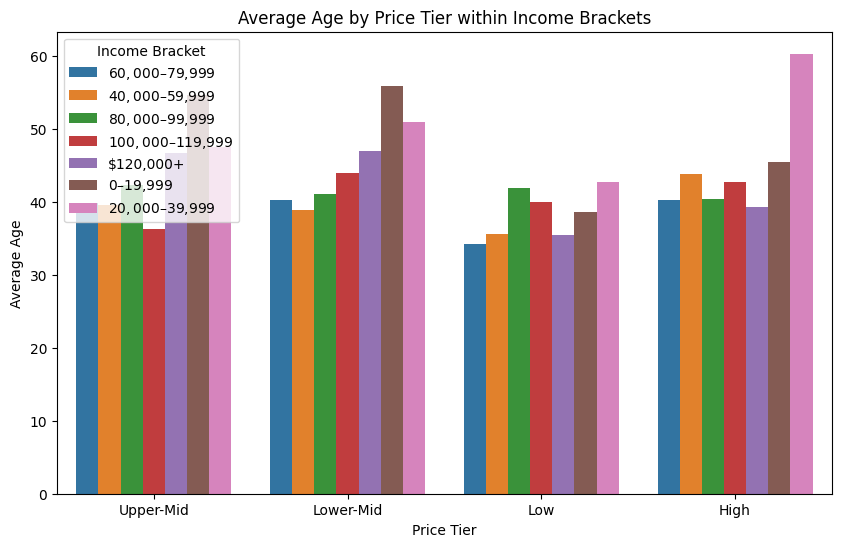

/tmp/ipython-input-2950959465.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Price Tier', y='dependents', hue='income_bracket', ci=None)


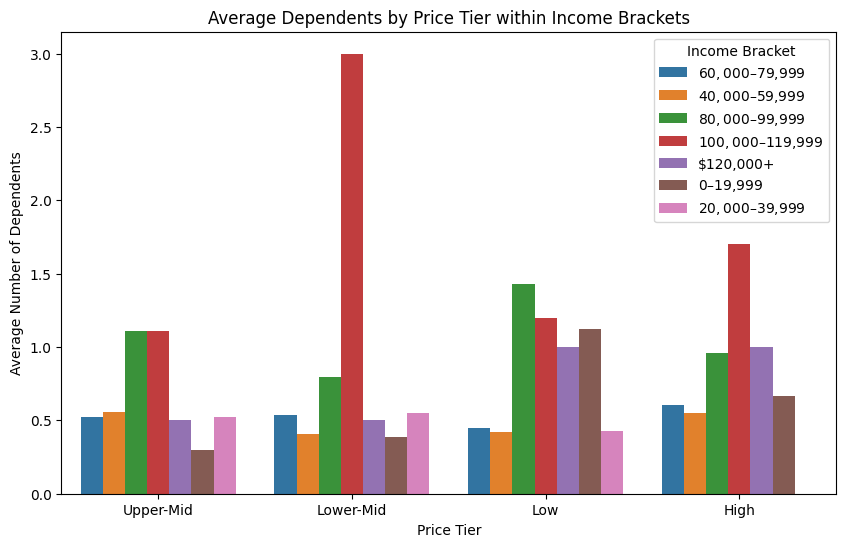

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age by Price Tier within each Income Bracket
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Price Tier', y='age', hue='income_bracket', ci=None)
plt.title('Average Age by Price Tier within Income Brackets')
plt.xlabel('Price Tier')
plt.ylabel('Average Age')
plt.legend(title='Income Bracket')
plt.show()

# Dependents by Price Tier within each Income Bracket
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Price Tier', y='dependents', hue='income_bracket', ci=None)
plt.title('Average Dependents by Price Tier within Income Brackets')
plt.xlabel('Price Tier')
plt.ylabel('Average Number of Dependents')
plt.legend(title='Income Bracket')
plt.show()


## Regression

In [ ]:
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')
df_edits = df.dropna(subset=['Maximum Resale Price', 'age', 'income_bracket'])


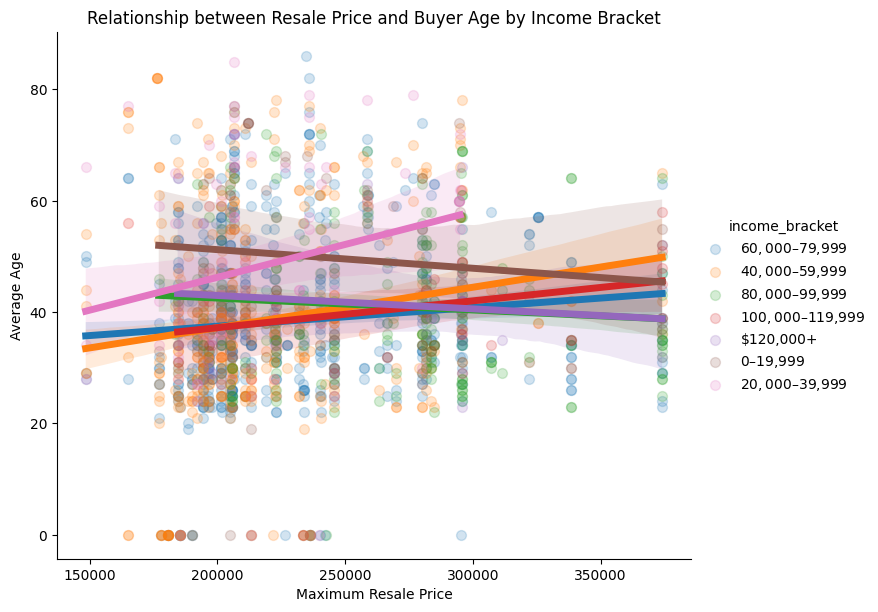

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=df,
    x='Maximum Resale Price',
    y='age',
    hue='income_bracket',    # separate regression line per bracket
    height=6,
    aspect=1.2,
    scatter_kws={'alpha': 0.2, 's': 50},
    line_kws={'lw': 5}
)

plt.title("Relationship between Resale Price and Buyer Age by Income Bracket")
plt.xlabel("Maximum Resale Price")
plt.ylabel("Average Age")
plt.show()




## Slope of Age vs Resale Price per Income Bracket

$0–$19,999: slope = -0.000033, p = 0.5546
$100,000–$119,999: slope = 0.000048, p = 0.1337
$120,000+: slope = -0.000024, p = 0.6639
$20,000–$39,999: slope = 0.000118, p = 0.0460
$40,000–$59,999: slope = 0.000073, p = 0.0008
$60,000–$79,999: slope = 0.000034, p = 0.0138
$80,000–$99,999: slope = -0.000021, p = 0.1946


/tmp/ipython-input-200890117.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slope_df, x='income_bracket', y='slope_age_vs_price', palette='coolwarm')


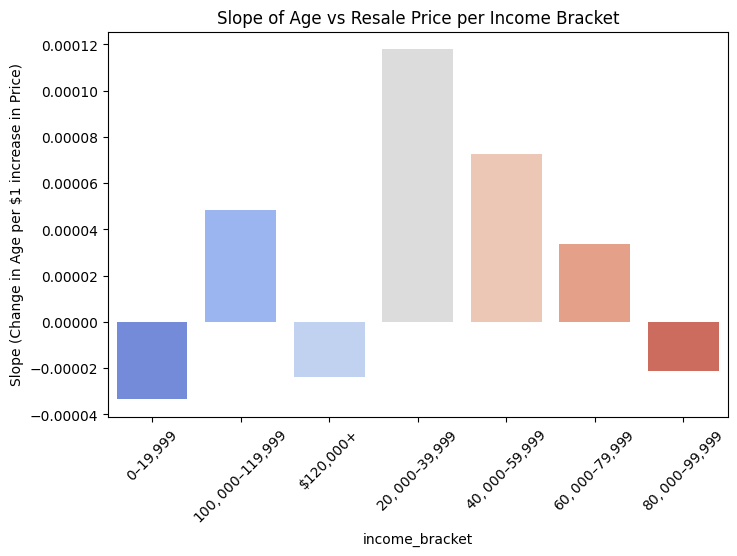

In [ ]:
import statsmodels.formula.api as smf

results = {}
for bracket, sub in df.groupby('income_bracket'):
    model = smf.ols('age ~ Q("Maximum Resale Price")', data=sub).fit()
    results[bracket] = model.params['Q("Maximum Resale Price")']
    print(f"{bracket}: slope = {model.params['Q(\"Maximum Resale Price\")']:.6f}, p = {model.pvalues['Q(\"Maximum Resale Price\")']:.4f}")
import pandas as pd
slope_df = pd.DataFrame({
    'income_bracket': results.keys(),
    'slope_age_vs_price': results.values()
})

plt.figure(figsize=(8,5))
sns.barplot(data=slope_df, x='income_bracket', y='slope_age_vs_price', palette='coolwarm')
plt.title("Slope of Age vs Resale Price per Income Bracket")
plt.ylabel("Slope (Change in Age per $1 increase in Price)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
model_interaction = smf.ols('age ~ Q("Maximum Resale Price") * C(income_bracket)', data=df).fit()
print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     6.274
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.28e-11
Time:                        20:14:34   Log-Likelihood:                -6105.7
No. Observations:                1472   AIC:                         1.224e+04
Df Residuals:                    1458   BIC:                         1.231e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

## Effect of Resale Price on Disability Probability per Income Bracket

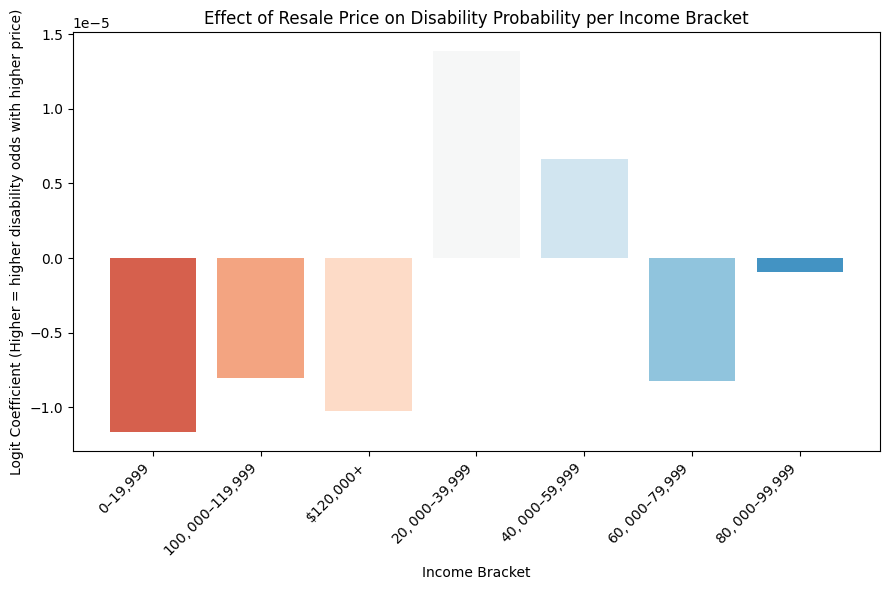

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Ensure disability is numeric (0/1)
# Convert disability to numeric, ignoring blanks
df["disability"] = pd.to_numeric(df["disability"], errors="coerce").astype("Int64")

# Container for results
slopes = []

for bracket, group in df.groupby("income_bracket"):
    if group["Maximum Resale Price"].nunique() > 1:
        X = sm.add_constant(group["Maximum Resale Price"])
        y = group["disability"]
        model = sm.Logit(y, X).fit(disp=0)  # logistic regression
        slope = model.params["Maximum Resale Price"]
        slopes.append({"income_bracket": bracket, "slope": slope})

# Create a dataframe
slopes_df = pd.DataFrame(slopes)

# Sort by income bracket for visualization
slopes_df = slopes_df.sort_values(by="income_bracket")

# Visualization
plt.figure(figsize=(9,6))
colors = plt.cm.RdBu(np.linspace(0.2, 0.8, len(slopes_df)))

plt.bar(slopes_df["income_bracket"], slopes_df["slope"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.title("Effect of Resale Price on Disability Probability per Income Bracket")
plt.ylabel("Logit Coefficient (Higher = higher disability odds with higher price)")
plt.xlabel("Income Bracket")
plt.tight_layout()
plt.show()


## Effect of Maximum Resale Price on Household Size per Income Bracket

/tmp/ipython-input-1108041418.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bracket, sub in df.groupby('income_bracket'):


$0–$19,999: slope = -0.0000, p = 0.8754
$20,000–$39,999: slope = -0.0000, p = 0.2369
$40,000–$59,999: slope = 0.0000, p = 0.0480
$60,000–$79,999: slope = 0.0000, p = 0.2311
$80,000–$99,999: slope = -0.0000, p = 0.2095
$100,000–$119,999: slope = 0.0000, p = 0.5130
$120,000+: slope = 0.0000, p = 0.8759


/tmp/ipython-input-1108041418.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slope_df, x='income_bracket', y='slope_price_on_dependents', palette='coolwarm')


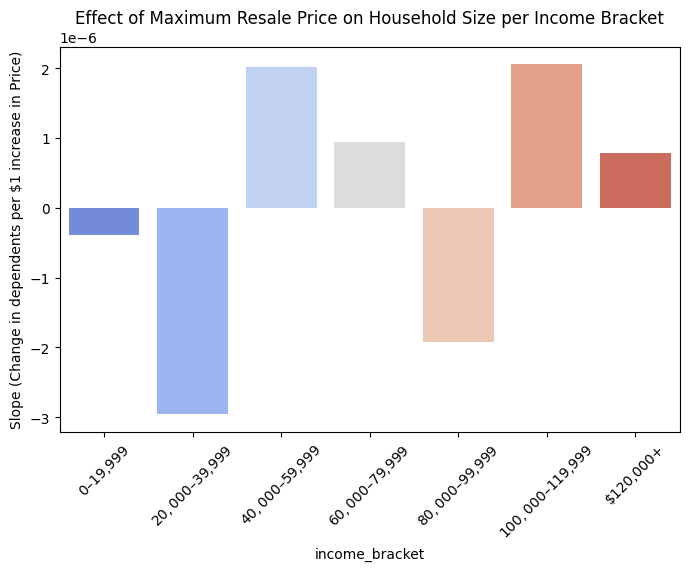

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = {}
for bracket, sub in df.groupby('income_bracket'):
    model = smf.ols('dependents ~ Q("Maximum Resale Price")', data=sub).fit()
    slope = model.params['Q("Maximum Resale Price")']
    pval = model.pvalues['Q("Maximum Resale Price")']
    results[bracket] = (slope, pval)
    print(f"{bracket}: slope = {slope:.4f}, p = {pval:.4f}")

slope_df = pd.DataFrame({
    'income_bracket': results.keys(),
    'slope_price_on_dependents': [v[0] for v in results.values()]
})

plt.figure(figsize=(8,5))
sns.barplot(data=slope_df, x='income_bracket', y='slope_price_on_dependents', palette='coolwarm')
plt.title("Effect of Maximum Resale Price on Household Size per Income Bracket")
plt.ylabel("Slope (Change in dependents per $1 increase in Price)")
plt.xticks(rotation=45)
plt.show()


## Correlarion heatmaps between applicant demographics & property price across different income brackets

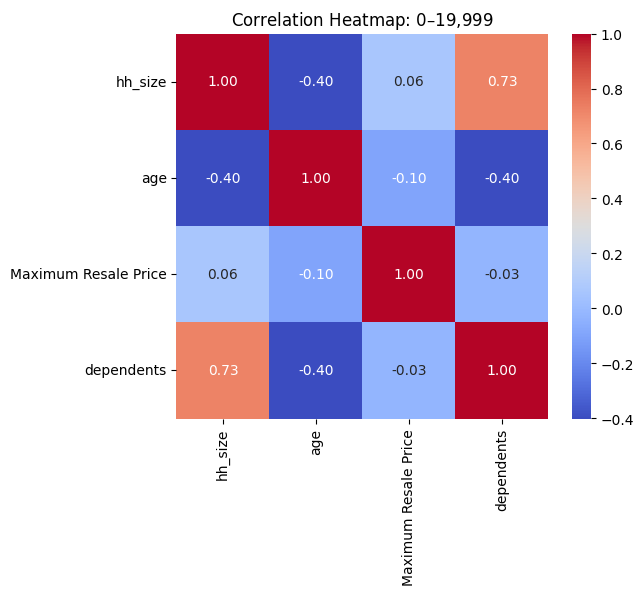

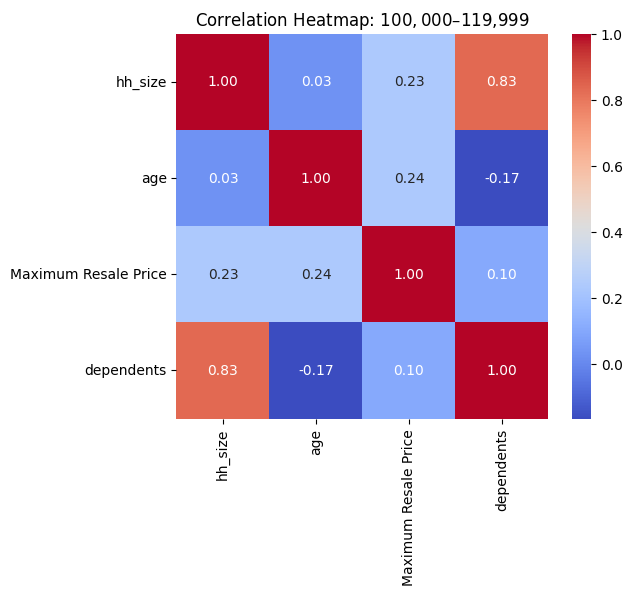

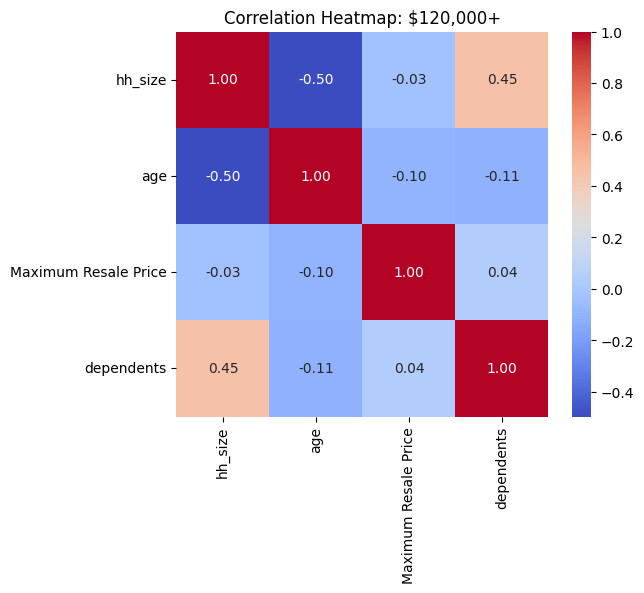

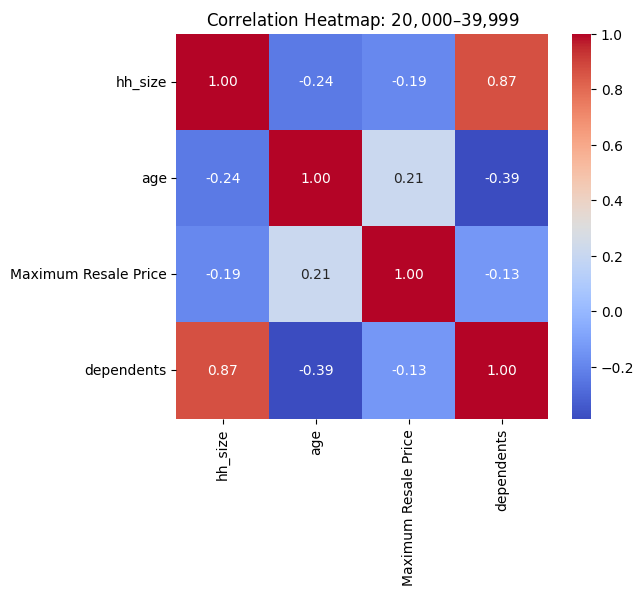

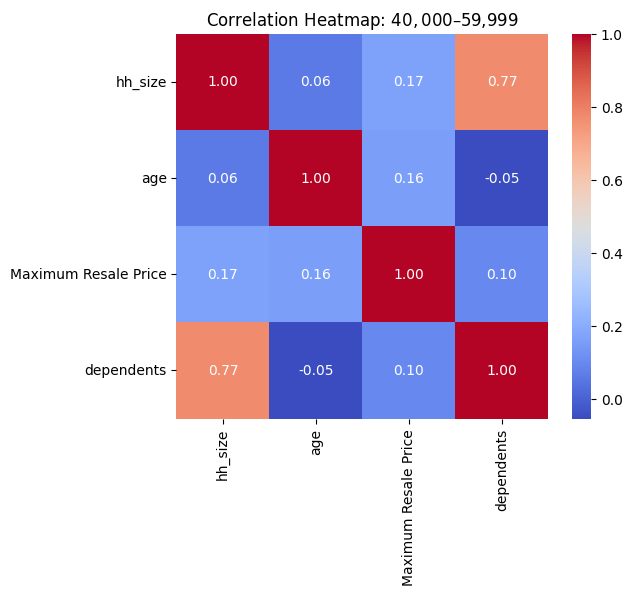

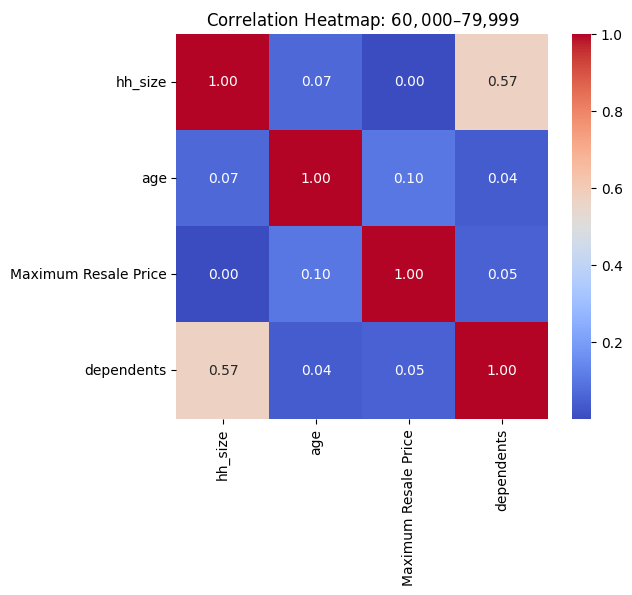

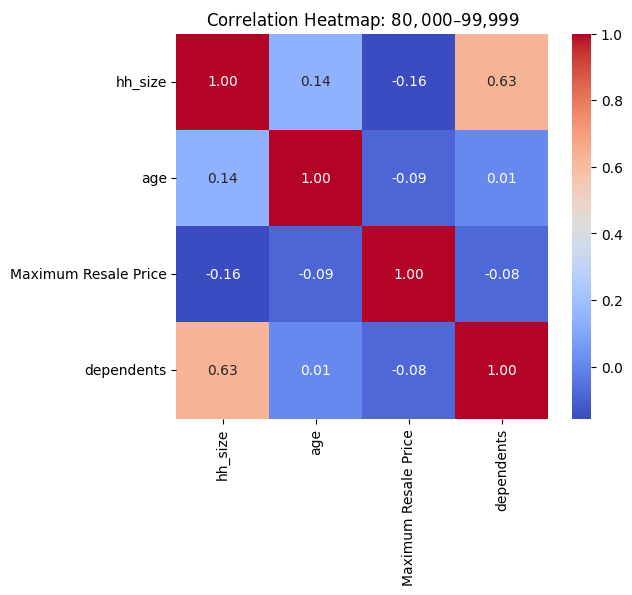

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_cols = ['hh_size', 'age', 'Maximum Resale Price', 'dependents']  # add others as needed
corr_matrix = df[numeric_cols].corr()

# Plot

import pandas as pd

for bracket, sub in df.groupby('income_bracket'):
    corr_matrix = sub[numeric_cols].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f"Correlation Heatmap: {bracket}")
    plt.show()


In [ ]:
df["income_bracket"].unique()

array(['$60,000–$79,999', '$40,000–$59,999', nan, '$80,000–$99,999',
       '$100,000–$119,999', '$120,000+', '$0–$19,999', '$20,000–$39,999'],
      dtype=object)

## Average Household Size by Price Tier per Income Bracket

/tmp/ipython-input-4202226259.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(['income_bracket', 'Price Tier'])['hh_size'].mean().reset_index()


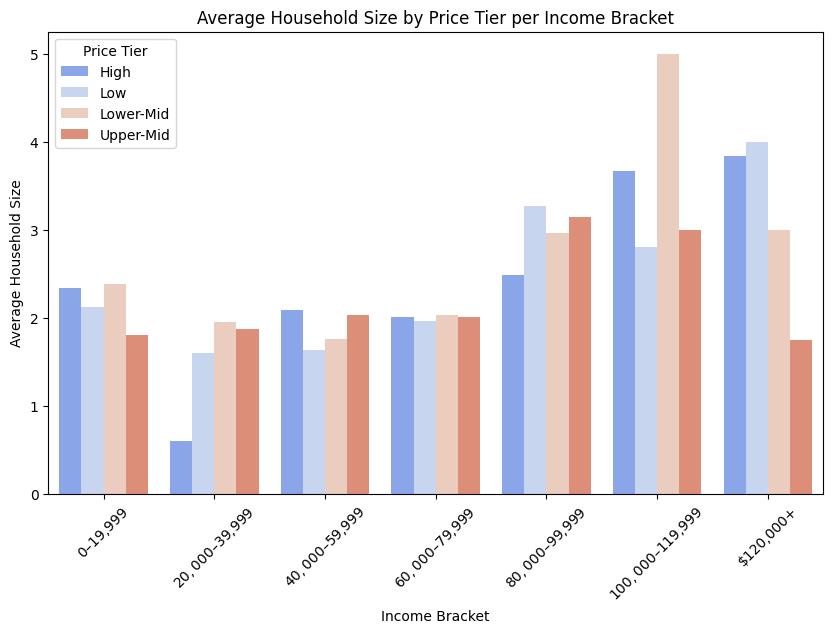

In [ ]:
import pandas as pd
import numpy as np

# Define ascending order
income_order = [
    '$0–$19,999',
    '$20,000–$39,999',
    '$40,000–$59,999',
    '$60,000–$79,999',
    '$80,000–$99,999',
    '$100,000–$119,999',
    '$120,000+'
]

# Convert to categorical with defined order
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=income_order, ordered=True)

# Create 3 price tiers (Low, Mid, High) based on quantiles

agg_df = df.groupby(['income_bracket', 'Price Tier'])['hh_size'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data=agg_df,
    x='income_bracket',
    y='hh_size',
    hue='Price Tier',
    palette='coolwarm'
)
plt.title("Average Household Size by Price Tier per Income Bracket")
plt.ylabel("Average Household Size")
plt.xlabel("Income Bracket")
plt.xticks(rotation=45)
plt.legend(title="Price Tier")
plt.show()


## Household Type Distribution per Price Tier & Income Bracket

In [ ]:
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=income_order, ordered=True)

# Create price tiers if not already done
#df['price_tier'] = pd.qcut(df['Maximum Resale Price'], q=3, labels=['Low', 'Mid', 'High'])


/tmp/ipython-input-466265462.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df['proportion'] = count_df.groupby(['income_bracket', 'Price Tier'])['count'].transform(lambda x: x / x.sum())


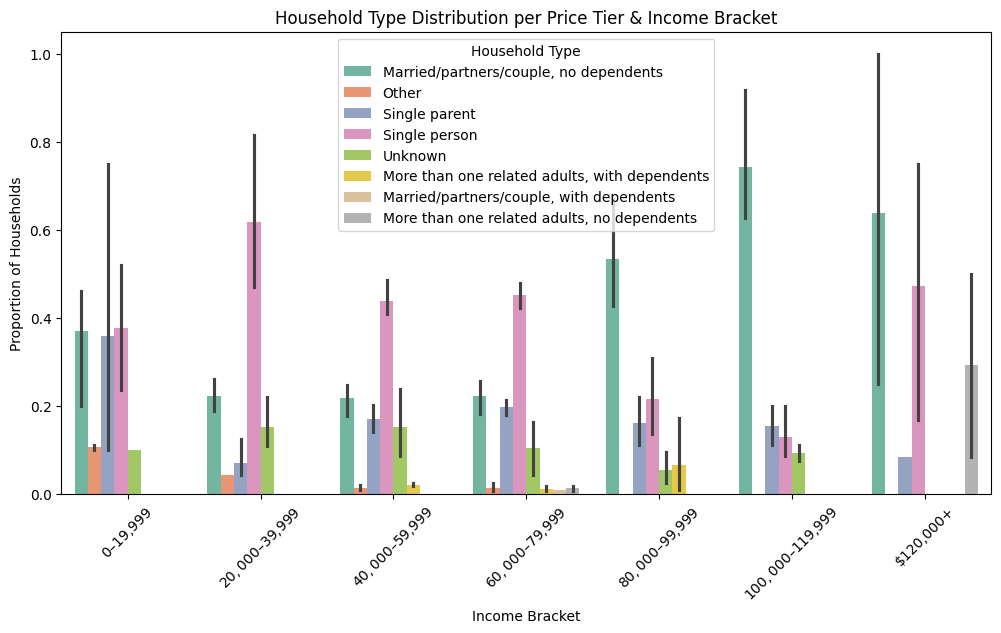

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure income_bracket is ordered
income_order = [
    '$0–$19,999',
    '$20,000–$39,999',
    '$40,000–$59,999',
    '$60,000–$79,999',
    '$80,000–$99,999',
    '$100,000–$119,999',
    '$120,000+'
]
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=income_order, ordered=True)

# Compute counts per income_bracket, price tier, hh_type
count_df = df.groupby(['income_bracket', 'Price Tier', 'hh_type'], observed=True).size().reset_index(name='count')

# Compute proportion within each income_bracket + price tier
count_df['proportion'] = count_df.groupby(['income_bracket', 'Price Tier'])['count'].transform(lambda x: x / x.sum())

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=count_df,
    x='income_bracket',
    y='proportion',
    hue='hh_type',
    palette='Set2'
)
plt.title("Household Type Distribution per Price Tier & Income Bracket")
plt.ylabel("Proportion of Households")
plt.xlabel("Income Bracket")
plt.xticks(rotation=45)
plt.legend(title="Household Type")
plt.show()


## Household Type Distribution per Price Tier by Income Bracket

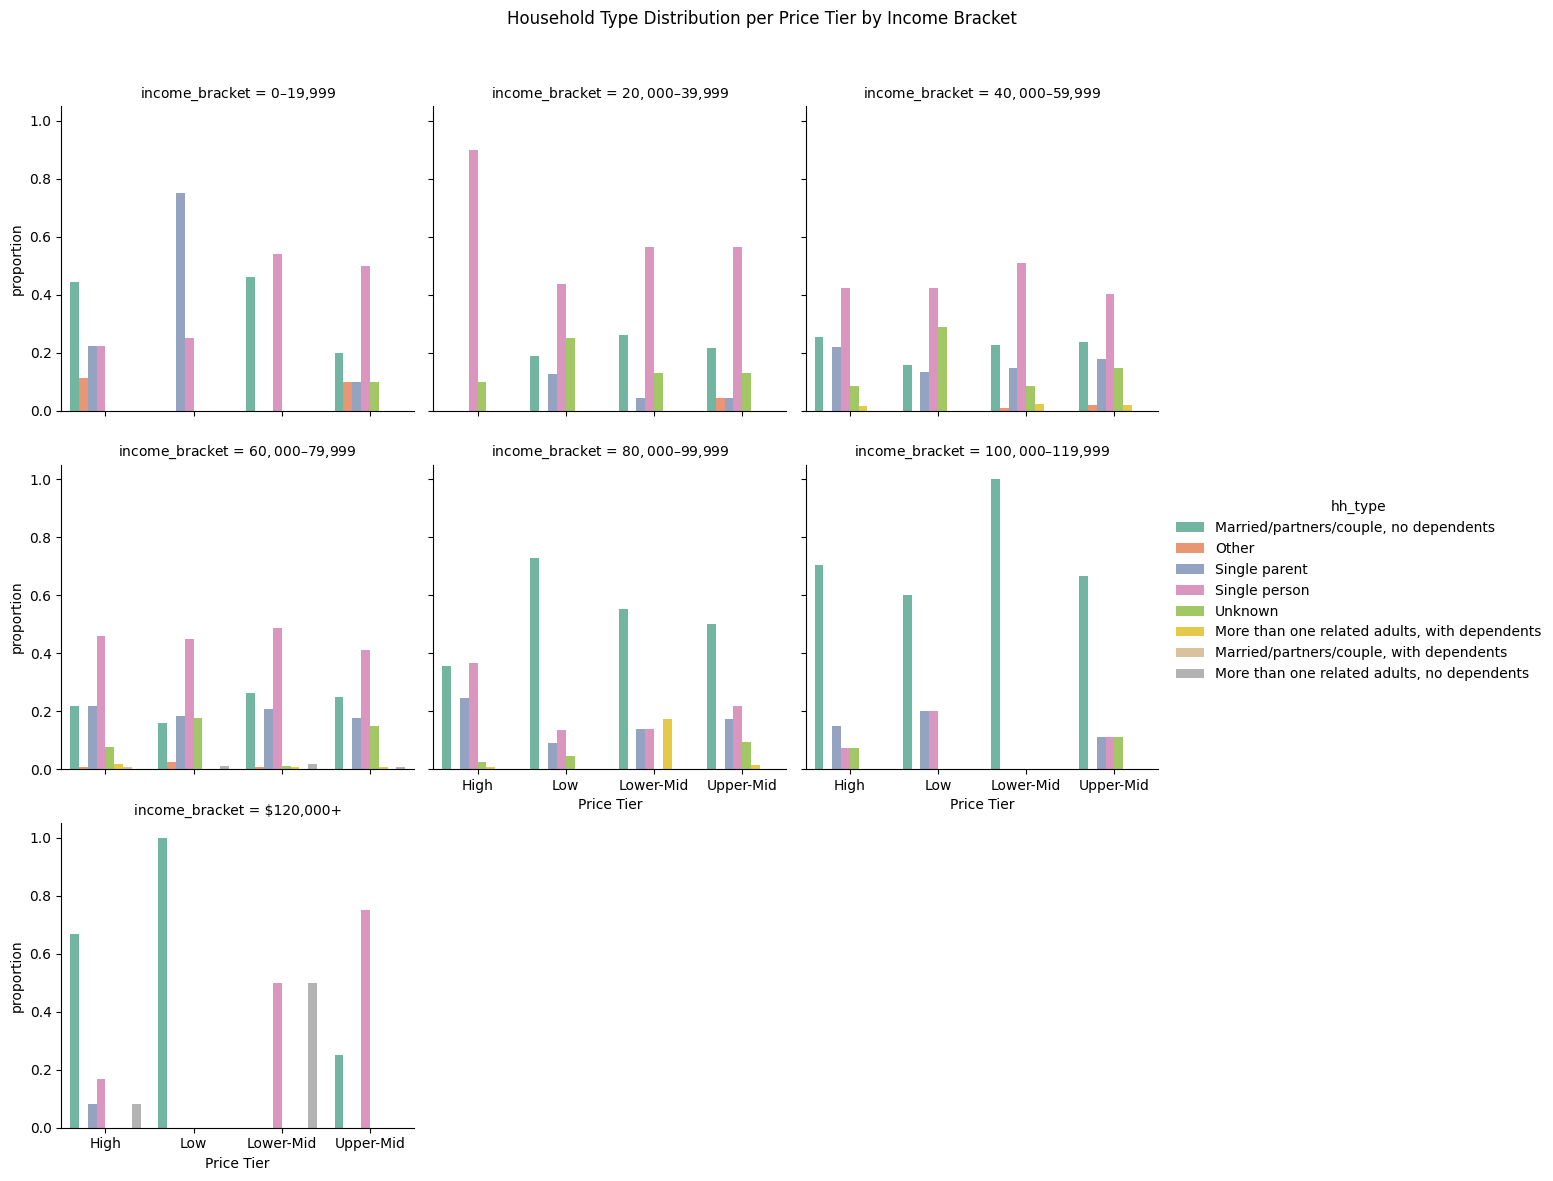

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=count_df,
    x='Price Tier',
    y='proportion',
    hue='hh_type',
    col='income_bracket',
    kind='bar',
    col_wrap=3,
    height=4,
    palette='Set2'
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Household Type Distribution per Price Tier by Income Bracket")
plt.show()


## Number of Properties per Town by Price Tier

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure price tier exists (you said it already does)
# df['Price Tier'] = ...

# Optional: filter out missing towns or incomes
df_plot = df.dropna(subset=['Town', 'Price Tier', 'hh_income'])


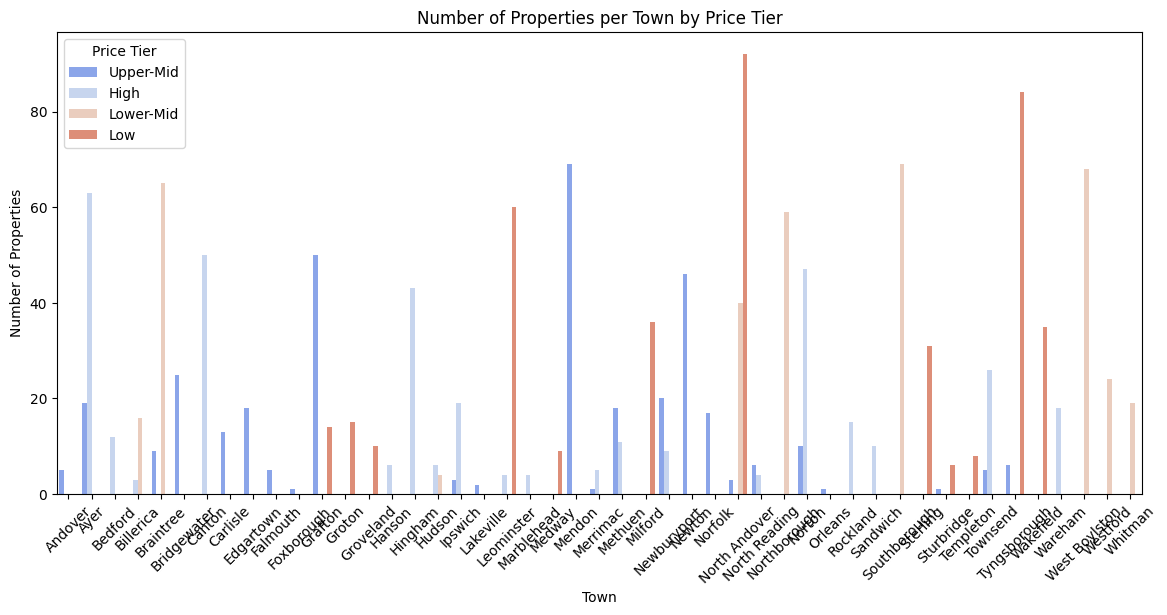

In [ ]:
plt.figure(figsize=(14,6))
sns.countplot(
    data=df_plot,
    x='Town',
    hue='Price Tier',
    palette='coolwarm'
)
plt.title("Number of Properties per Town by Price Tier")
plt.ylabel("Number of Properties")
plt.xlabel("Town")
plt.xticks(rotation=45)
plt.legend(title="Price Tier")
plt.show()


## Proportion of Applicant Sources per Price Tier

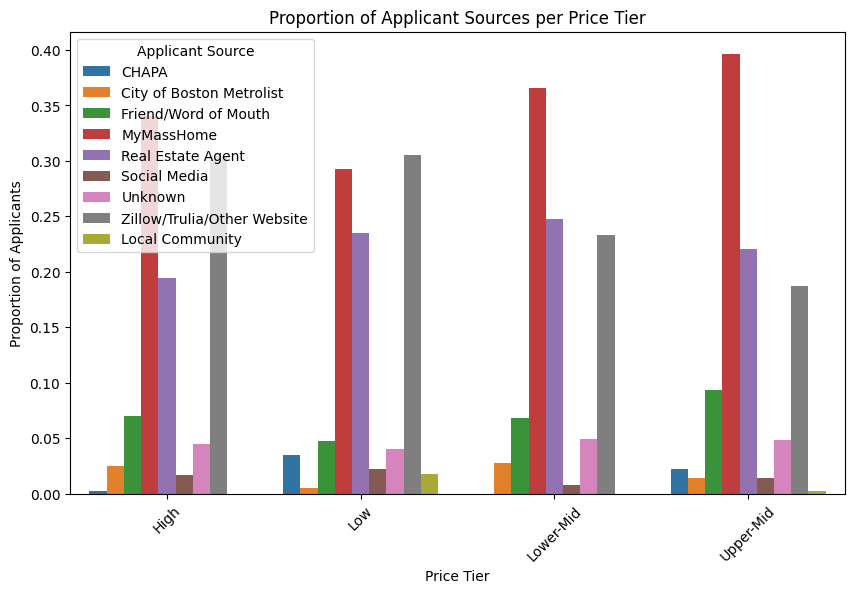

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy the dataframe to avoid modifying original
df_tmp = df_plot.copy()

# Compute counts per Price Tier + Applicant Source
counts = df_tmp.groupby(['Price Tier', 'application_source'], observed=True).size().reset_index(name='count')

# Compute proportion within each Price Tier
counts['proportion'] = counts.groupby('Price Tier')['count'].transform(lambda x: x / x.sum())

# Plot as barplot
plt.figure(figsize=(10,6))
sns.barplot(
    data=counts,
    x='Price Tier',
    y='proportion',
    hue='application_source'
)
plt.title("Proportion of Applicant Sources per Price Tier")
plt.ylabel("Proportion of Applicants")
plt.xlabel("Price Tier")
plt.xticks(rotation=45)
plt.legend(title="Applicant Source")
plt.show()


## Analysis of those applicants for whom CHAPA is listed as a marketing source

#### Analyzing average age and distribution of applicants

In [ ]:
# Filter for applicant_source == 'CHAPA'
chapa_df = df_plot[df_plot['application_source'] == 'CHAPA']

# Compute average age
average_age = chapa_df['age'].mean()

print(f"Average age of applicants: {average_age:.2f} years")


Average age of applicants from CHAPA: 38.39 years


/tmp/ipython-input-4040318381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


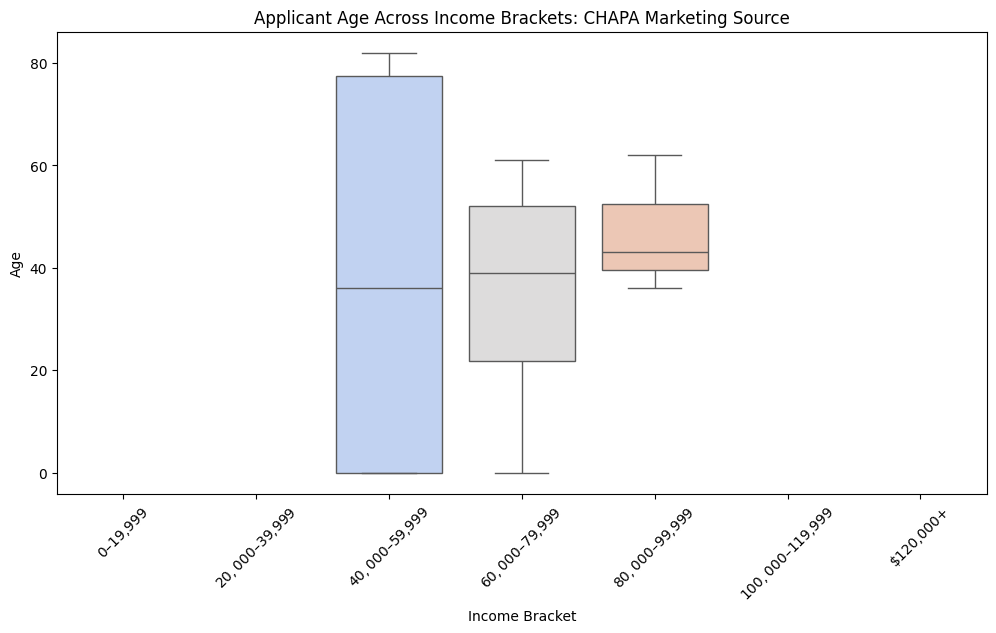

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: order income brackets if they're strings
income_order = ['$0–$19,999', '$20,000–$39,999', '$40,000–$59,999',
                '$60,000–$79,999', '$80,000–$99,999', '$100,000–$119,999', '$120,000+']

plt.figure(figsize=(12,6))
sns.boxplot(
    data=chapa_df,
    x='income_bracket',
    y='age',
    order=income_order,
    palette='coolwarm'
)
plt.title("Applicant Age Across Income Brackets: CHAPA Marketing Source")
plt.ylabel("Age")
plt.xlabel("Income Bracket")
plt.xticks(rotation=45)
plt.show()


#### Regression analysis: household size and property price

In [ ]:
chapa_df = df_plot[df_plot['application_source'] == 'CHAPA'].dropna(subset=['hh_size', 'income_bracket', 'Maximum Resale Price'])
import statsmodels.formula.api as smf
import pandas as pd

results = {}
for bracket, sub in chapa_df.groupby('income_bracket', observed=True):
    model = smf.ols('hh_size ~ Q("Maximum Resale Price")', data=sub).fit()
    results[bracket] = {
        'slope': model.params['Q("Maximum Resale Price")'],
        'p_value': model.pvalues['Q("Maximum Resale Price")']
    }

# Convert results to DataFrame
slope_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'income_bracket'})
print(slope_df)


    income_bracket         slope   p_value
0  $40,000–$59,999  4.892117e-06  0.132999
1  $60,000–$79,999  4.065890e-07  0.964107
2  $80,000–$99,999 -6.258606e-05  0.333333


#### Regression analysis: number of dependents and property price

In [ ]:
chapa_df = df_plot[df_plot['application_source'] == 'CHAPA'].dropna(subset=['dependents', 'income_bracket', 'Maximum Resale Price'])
import statsmodels.formula.api as smf
import pandas as pd

results = {}
for bracket, sub in chapa_df.groupby('income_bracket', observed=True):
    model = smf.ols('dependents ~ Q("Maximum Resale Price")', data=sub).fit()
    results[bracket] = {
        'slope': model.params['Q("Maximum Resale Price")'],
        'p_value': model.pvalues['Q("Maximum Resale Price")']
    }

# Convert results to DataFrame
slope_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'income_bracket'})
print(slope_df)


    income_bracket     slope       p_value
0  $40,000–$59,999  0.000012  1.702848e-02
1  $60,000–$79,999 -0.000006  4.233940e-01
2  $80,000–$99,999 -0.000042  2.398925e-15
